# ROGUE Purity Audit — per (sample, K, GEP) with split/merge scoring

For every cNMF resolution K and every GEP within K, assign each cell to its argmax-usage GEP and compute ROGUE per **(sample, K, GEP)** on the cNMF HVG substrate. Each row carries the tree label `assign_celltype` gave that GEP in `celltype_gated_correlation.ipynb` as **metadata**, not as the grouping key. A HVG-space baseline ROGUE is computed for both specific labels (§6) and family pools (§6b); the two tables are then joined per `(sample, K, GEP)` so we can ask, for each GEP at each K, whether its cell subset is purer than the original-annotation block whose label it carries.


## Split/merge logic

For each `(sample, K, GEP)` row, the **`membership_label`** points us to a baseline:

* **Specific label** (e.g. `cDC2_CD1C`): baseline = HVG ROGUE of the original `cDC2_CD1C` cells in that sample. `Δ ROGUE > 0` means cNMF found a purer subset of the original annotation → **evidence for splitting** the original label.
* **Subgroup label** (e.g. `Mono_CD14+Mono_CD14_IL1B`): baseline = HVG ROGUE of the pool of just those constituent original labels in that sample. Three reference points are computed — `mean`, `min`, `max` ROGUE across the constituents. If the subgroup GEP beats the `max`, the subgroup is strictly purer than any single constituent → **evidence for merging that specific subset of subtypes** (without committing to merging the whole family).
* **Family label** (e.g. `Monocyte_family`): baseline = HVG ROGUE of the union of *all* constituent original labels in that sample. Same three reference points (mean/min/max). If the family GEP beats the `max`, the entire family-level grouping is strictly purer than any single constituent → **evidence for merging the full family**.
* **Ambiguous/Mixed**: no baseline; reported individually. High ROGUE here means the GEP is internally coherent but didn't pass the dominance threshold in §3 of notebook 2 — useful for tuning `AMBIGUITY_THRESHOLD`.

## Gene-space convention
All ROGUE values in this notebook are on the **same 5K HVG matrix** used by cNMF — both the per-GEP scores and every baseline (specific, subgroup, family). This makes Δ ROGUE interpretable as "the GEP found a purer subset *in the same gene space*." The absolute values are systematically lower than the full-transcriptome scores in notebook 3 and should not be compared to the 0.9 threshold from Liu et al. (2020); use notebook 3's CSV for that.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE


In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

## 1. Config


In [2]:
# Paths
ADATA_PATH = "data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None

METADATA_PATH = "data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL = None
METADATA_SEP = ","

CNMF_DIR = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35

# Per-GEP labels from the cell-type correlation notebook
LABELS_PATH = "combined-hnc_k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"
LABELS_SEP = "\t"
AMBIGUOUS_LABEL = "Ambiguous/Mixed"
DROP_AMBIGUOUS = False

BASELINE_LABEL_COL = "global.cluster4"


# Cell-type families; must match notebook 2
CELLTYPE_FAMILIES = {
    "Monocyte": [
        "Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
        "Mono_CD16", "Mono_Int", "Mono_TIL"
    ],
    "DC": [
        "cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "mregDC_LAMP3"
    ],
    "Macrophage": [
        "Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"
    ],
}
FAMILY_LABEL_SUFFIX = "_family"

# Empirical subgroup detection from original labels of cells assigned to each GEP
SUBFAMILY_MIN_FRAC_PER_SUBTYPE = 0.15  # each kept subtype must be ≥ this fraction of GEP cells
SUBFAMILY_MIN_CUMFRAC          = 0.60  # the kept set together must cover ≥ this fraction
SUBFAMILY_MIN_COUNT = 15     # minimum subtype cell count
SUBFAMILY_MAX_SIZE = 3       # maximum number of subtypes in a subgroup

# ROGUE settings
ROGUE_PLATFORM = "UMI"
ROGUE_SPECIES = "Human"
ROGUE_K = 45
MIN_CELLS_PER_GROUP = 15

# Gene space and signal threshold
N_HVG = 5000
DELTA_ROGUE_THRESHOLD = 0.05

# Output
OUT_DIR = "rogue_purity_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)

print("Configuration loaded.")

Configuration loaded.


## 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# Get raw counts as a dense genes × cells matrix (ROGUE expects this orientation)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

# Sanity check: ROGUE assumes raw counts (integer-valued, non-negative)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

# Metadata (used for per-cell sample IDs AND original cell-type annotation)
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
samples = meta['orig.ident']
original_labels = meta[BASELINE_LABEL_COL].astype(str)
print(f"Aligned to {len(common)} cells")
print(f"Original annotation column ('{BASELINE_LABEL_COL}') values:")
print(original_labels.value_counts().to_string())

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells
Original annotation column ('global.cluster4') values:
global.cluster4
Mono_CD14          7518
Mono_CD16          2503
Mac_IL1Bint        1842
Mono_CD14_IL1B     1801
Mono_CD14_THBS1    1783
Mono_Int           1684
cDC2_CD33          1319
Mac_CXCL9          1225
DC_pDC             1218
Mono_CD14_ID1      1154
Mono_TIL            988
cDC2_CD1C           966
Mac_IL1B            774
Mac_SPP1            573
mregDC_LAMP3        482
Mast                313
cDC1_CLEC9A         301


## 3. ROGUE wrapper


In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, species=ROGUE_SPECIES,
                  k=ROGUE_K, min_cells=MIN_CELLS_PER_GROUP,
                  verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    # --- Filter tiny groups ---
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    # --- Build (sample, cluster) work list ---
    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        print()

    # --- Push the full counts matrix to R once ---
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r("""
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    """)

    # --- Per-(sample, cluster) loop in Python ---
    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f"""
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            """)
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

## 4. Load per-GEP labels from the correlation-tree pipeline

Reads `per_gep_labels.tsv` (the output of `assign_celltype()` from `celltype_gated_correlation.ipynb`), validates that it has `k`, `gep`, `label` columns, normalizes types (`k` int, `gep` str, `label` str), and builds `label_lookup: (k, gep_id) → label` as a dict for O(1) access.

Cross-checks: every label in the TSV should be either an original cell type in` global.cluster4`, a `<family>_family` label, or `"Ambiguous/Mixed"`. Anything else gets flagged because it'll silently become `'no_baseline'` in §7's join. The gep cast to string matters because `usage.idxmax(axis=1)` in §7 returns strings.

In [5]:
labels_df = pd.read_csv(LABELS_PATH, sep=LABELS_SEP)
required_cols = {"k", "gep", "label"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(
        f"per-GEP labels TSV is missing columns {missing}. "
        f"Expected schema: k, gep, label. Got: {list(labels_df.columns)}"
    )

labels_df['k']     = labels_df['k'].astype(int)
labels_df['gep']   = labels_df['gep'].astype(str)
labels_df['label'] = labels_df['label'].astype(str)

# Build a fast lookup: (k, gep_id) -> label
label_lookup = (labels_df
                .set_index(['k', 'gep'])['label']
                .to_dict())

print(f"Loaded labels for {len(labels_df)} (k, gep) entries "
      f"across K = {sorted(labels_df['k'].unique())}")
print(f"Unique labels: {sorted(labels_df['label'].unique())}")
n_amb = (labels_df['label'] == AMBIGUOUS_LABEL).sum()
print(f"  ({n_amb} GEPs labeled '{AMBIGUOUS_LABEL}')")

# Cross-check: every specific label in the TSV should be a known cell type
# in the baseline annotation, otherwise the §7 join will fail silently.
known_originals = set(original_labels.unique())
known_families  = {f"{fam}{FAMILY_LABEL_SUFFIX}" for fam in CELLTYPE_FAMILIES}
unknown = (set(labels_df['label']) - known_originals - known_families - {AMBIGUOUS_LABEL})
if unknown:
    print(f"  ⚠ Labels in TSV not found in the original annotation OR "
          f"the family definitions: {sorted(unknown)}.")
    print("    These rows will be flagged 'no_baseline' in §7.")

Loaded labels for 627 (k, gep) entries across K = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
Unique labels: ['Ambiguous/Mixed', 'DC_family', 'DC_pDC', 'Mac_IL1B', 'Mac_SPP1', 'Macrophage_family', 'Mast', 'Mono_CD14_ID1', 'Mono_CD16', 'Monocyte_family', 'cDC2_CD33']
  (452 GEPs labeled 'Ambiguous/Mixed')


### 4b. Diagnostic — which specific subtypes did `assign_celltype` actually emit?

Catches **filter 1**: a family constituent (e.g. `cDC2_CD1C`) is part of
`CELLTYPE_FAMILIES` but never appears as a specific label in the per-GEP TSV
because every GEP that should have carried it failed the
`AMBIGUITY_THRESHOLD` dominance check in notebook 2 and got rerouted to
`<family>_family` or `Ambiguous/Mixed`. These subtypes are invisible to
every downstream step of this notebook — they have no row in §6, no row in
§7, no row in §10. Without this check, that silent absence looks the same
as "no signal."


In [6]:
# Which specific subtypes did assign_celltype emit at least once?
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())

# Universe of subtypes we *expected* to see (family constituents).
# Other specific labels (e.g. lymphoid/non-myeloid) outside any family are
# not checked here — they're either present in `specific_in_tsv` or were
# never relevant to begin with.
all_family_constituents = {ct
                           for cts in CELLTYPE_FAMILIES.values()
                           for ct in cts}

never_labeled = sorted(all_family_constituents - specific_in_tsv)
labeled_constituents = sorted(all_family_constituents & specific_in_tsv)

print(f"Family-constituent subtypes that DID get a specific label "
      f"at some K: {len(labeled_constituents)}/{len(all_family_constituents)}")
for ct in labeled_constituents:
    n_geps = (labels_df['label'] == ct).sum()
    n_K = labels_df.loc[labels_df['label'] == ct, 'k'].nunique()
    print(f"  ✓ {ct:<22} {n_geps:>4} GEPs across {n_K:>2} K values")

if never_labeled:
    print(f"\n⚠ Family-constituent subtypes NEVER emitted as a specific label "
          f"by assign_celltype: {never_labeled}")
else:
    print("\n✓ Every family constituent appears as a specific label at "
          "least once.")


Family-constituent subtypes that DID get a specific label at some K: 5/15
  ✓ Mac_IL1B                  2 GEPs across  2 K values
  ✓ Mac_SPP1                  4 GEPs across  4 K values
  ✓ Mono_CD14_ID1             4 GEPs across  4 K values
  ✓ Mono_CD16                 9 GEPs across  9 K values
  ✓ cDC2_CD33                 4 GEPs across  4 K values

⚠ Family-constituent subtypes NEVER emitted as a specific label by assign_celltype: ['Mac_CXCL9', 'Mac_IL1Bint', 'Mono_CD14', 'Mono_CD14_IL1B', 'Mono_CD14_THBS1', 'Mono_Int', 'Mono_TIL', 'cDC1_CLEC9A', 'cDC2_CD1C', 'mregDC_LAMP3']


## 5. Select the 5K highly variable genes (cNMF substrate)

Build a temporary `AnnData` wrapping `counts_df` (cells × genes orientation), then call `sc.pp.highly_variable_genes(..., flavor='seurat_v3', n_top_genes=5000)`. The `seurat_v3` flavor is designed for raw counts (it models the mean–variance trend using a loess fit on raw counts), which is what cNMF uses internally — so the HVG set is the same substrate cNMF saw.
counts_df_hvg is the 5000-gene × all-cells matrix that all downstream ROGUE calls operate on. Saved to disk for reproducibility.

**Gene-space caveat:** ROGUE's S-E test is calibrated against the whole-transcriptome mean–variance trend, and restricting to pre-selected HVGs biases the entropy reference. Absolute ROGUE values in this notebook are not comparable to the full-transcriptome run in the cell-type audit notebook or to the 0.9 threshold from Liu et al. (2020). All split/merge claims are made on **Δ ROGUE within this HVG space**, so the bias cancels.


In [7]:
_hvg_adata = ad.AnnData(
    X=counts_df.T.values,
    obs=pd.DataFrame(index=counts_df.columns),
    var=pd.DataFrame(index=counts_df.index),
)

sc.pp.highly_variable_genes(
    _hvg_adata,
    n_top_genes=N_HVG,
    flavor='seurat_v3',
    subset=False,
)

hvg_genes = _hvg_adata.var_names[_hvg_adata.var['highly_variable']].tolist()
print(f"Selected {len(hvg_genes)} HVGs out of {counts_df.shape[0]} total genes.")

counts_df_hvg = counts_df.loc[hvg_genes]
print(f"HVG counts matrix (genes × cells): {counts_df_hvg.shape}")

hvg_path = os.path.join(OUT_DIR, f"hvg_genes_n{N_HVG}_seuratv3.txt")
pd.Series(hvg_genes).to_csv(hvg_path, index=False, header=False)
print(f"  → saved gene list to {hvg_path}")

del _hvg_adata

Selected 5000 HVGs out of 23630 total genes.
HVG counts matrix (genes × cells): (5000, 26444)
  → saved gene list to rogue_purity_results_per_gep/hvg_genes_n5000_seuratv3.txt


## 6. Baseline ROGUE — specific original cell-type labels (HVG space)

The per-GEP ROGUE in §7 runs on the 5K HVG cNMF substrate, not the full transcriptome. ROGUE's S-E test is calibrated against whatever mean–variance trend is in the input matrix, so an HVG-restricted run and a full-transcriptome run produce different absolute ROGUE values for the same cells. If we used notebook 3's baseline directly, the §8 Δ ROGUE comparison would mix gene spaces, and a positive Δ could mean "the GEP found a purer subset" *or* "the GEP just got a more lenient entropy reference by being on HVGs." Comparing within a single gene space is the only way to make Δ ROGUE interpretable as a split/merge signal.

**This cell asks:** for each (sample, original_label) pair, what's the ROGUE purity of those cells in the HVG space `baseline_specific_lookup` is the resulting dict: `(sample, original_label) → ROGUE`. This is the comparison reference for `baseline_group_type == 'specific'` rows in §8.

In [8]:
baseline_specific_path = os.path.join(OUT_DIR, "rogue_baseline_specific.csv")

if os.path.exists(baseline_specific_path):
    baseline_specific = pd.read_csv(baseline_specific_path)
    print(f"Loaded cached specific-label baseline: {baseline_specific_path}")
else:
    print("Computing per-(sample, original cell type) baseline ROGUE …")
    baseline_specific, _ = compute_rogue(
        counts_df_hvg,
        labels=original_labels,
        samples=samples,
    )
    baseline_specific = baseline_specific.rename(columns={'cluster': 'original_label'})
    baseline_specific.to_csv(baseline_specific_path, index=False)
    print(f"  → saved {baseline_specific_path}")

# Per-sample lookup: (sample, original_label) -> baseline ROGUE
baseline_specific_lookup = (baseline_specific
                            .set_index(['sample', 'original_label'])['ROGUE']
                            .to_dict())
print(f"\nBaseline (specific labels): {len(baseline_specific)} (sample, label) pairs")
print(baseline_specific.groupby('original_label')['ROGUE']
                        .agg(['mean', 'median', 'count'])
                        .round(3).to_string())

Loaded cached specific-label baseline: rogue_purity_results_per_gep/rogue_baseline_specific.csv

Baseline (specific labels): 312 (sample, label) pairs
                  mean  median  count
original_label                       
DC_pDC           0.928   0.944     30
Mac_CXCL9        0.810   0.824     13
Mac_IL1B         0.825   0.831     10
Mac_IL1Bint      0.794   0.794     21
Mac_SPP1         0.801   0.808      7
Mast             0.943   0.950      7
Mono_CD14        0.976   0.976     36
Mono_CD14_ID1    0.936   0.943      5
Mono_CD14_IL1B   0.953   0.962     24
Mono_CD14_THBS1  0.969   0.983     11
Mono_CD16        0.958   0.964     33
Mono_Int         0.969   0.970     27
Mono_TIL         0.862   0.855     13
cDC1_CLEC9A      0.895   0.909      6
cDC2_CD1C        0.781   0.791     21
cDC2_CD33        0.927   0.934     36
mregDC_LAMP3     0.864   0.873     12


### 6b. Baseline ROGUE — family pools (HVG space)

The `baseline_family` measure is constructed entirely from the original `global.cluster4` annotations (the “original_labels”) and the static `CELLTYPE_FAMILIES` dictionary from the configuration. 

For each cell, we generate a `family_labels_per_cell` Series that maps it to `<family>_family` if its original label belongs to any predefined family (cells without a family assignment are dropped). 
- For example, a cell originally annotated as `Mono_CD14_IL1B` will always be pooled into `Monocyte_family`—no matter which GEP it argmax‑es to at any K, and regardless of whether notebook 2 called that GEP `Monocyte_family`, `Mono_CD14`, or `Ambiguous/Mixed` `baseline_family[(P12, Monocyte_family)]` is then the **ROGUE purity** of *all* cells from patient P12 whose original annotation falls into any of the monocyte‑related subtypes pooled together as a single group and scored. 
- This defines a clean **null hypothesis**: “If we simply merge all monocyte subtypes using their original labels, how pure would that pooled group be?” A family‑labeled GEP must exceed this baseline to justify merging the subtypes into a single family.

In [9]:
baseline_family_path = os.path.join(OUT_DIR, "rogue_baseline_family.csv")

# Build a cell -> family label series for the pool ROGUE
ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}
family_labels_per_cell = original_labels.map(
    lambda ct: f"{ct_to_family[ct]}{FAMILY_LABEL_SUFFIX}" if ct in ct_to_family else None
).dropna()
print(f"Cells in any family pool: {len(family_labels_per_cell)} "
      f"(across {family_labels_per_cell.nunique()} families)")

if os.path.exists(baseline_family_path):
    baseline_family = pd.read_csv(baseline_family_path)
    print(f"Loaded cached family-pool baseline: {baseline_family_path}")
else:
    print("Computing per-(sample, family_pool) baseline ROGUE …")
    baseline_family, _ = compute_rogue(
        counts_df_hvg[family_labels_per_cell.index],
        labels=family_labels_per_cell,
        samples=samples.loc[family_labels_per_cell.index],
    )
    baseline_family = baseline_family.rename(columns={'cluster': 'family_label'})
    baseline_family.to_csv(baseline_family_path, index=False)
    print(f"  → saved {baseline_family_path}")

baseline_family_lookup = (baseline_family
                          .set_index(['sample', 'family_label'])['ROGUE']
                          .to_dict())

print(f"\nBaseline (family pools): {len(baseline_family)} (sample, family) pairs")
print(baseline_family.groupby('family_label')['ROGUE']
                       .agg(['mean', 'median', 'count'])
                       .round(3).to_string())

Cells in any family pool: 24913 (across 3 families)
Loaded cached family-pool baseline: rogue_purity_results_per_gep/rogue_baseline_family.csv

Baseline (family pools): 132 (sample, family) pairs
                    mean  median  count
family_label                           
DC_family          0.839   0.899     55
Macrophage_family  0.719   0.712     23
Monocyte_family    0.897   0.912     54


## 7. Per-(sample, K, GEP) ROGUE scan across K

In [10]:
# Discover available K values (same logic as the GSEA notebook)
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = []
for f in sorted(glob.glob(usage_pattern)):
    m = re.search(r'k_(\d+)', os.path.basename(f))
    if m:
        k = int(m.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)
k_values = sorted(set(k_values))
print(f"K values: {k_values}")

ks_in_labels = set(labels_df['k'].unique())
missing_labels = sorted(set(k_values) - ks_in_labels)
if missing_labels:
    print(f"  ⚠ K = {missing_labels} are present in cNMF outputs but absent from "
          f"the per-GEP labels TSV; they will be skipped.")
    k_values = [k for k in k_values if k in ks_in_labels]

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


**For each K:**
1. Per-K cache check: if `rogue_per_gep_K{k}.csv` already exists, load it and skip — re-running this notebook is O(disk).
2. Load the consensus usage matrix `usage` (n_cells × K, normalized factor loadings).
3. Hard-assign each cell to its argmax GEP: `gep_ids = usage.idxmax(axis=1)`. So GEP id at K=10 might be `'1', '2', ..., '10'` and each cell gets one of them.
4. Drop cells whose GEP isn't in the TSV: shouldn't happen if notebook 2 ran cleanly, but logged if it does.
5. Optionally drop ambiguous GEPs (`DROP_AMBIGUOUS=False` so kept).
6. Call `compute_rogue` grouping by GEP id, with `samples` as a separate axis. So `compute_rogue` produces one ROGUE per `(sample, GEP)` pair — not per GEP-pooled-across-samples. This is the crucial design choice: split/merge signal has to be measured within sample to be valid, because sample-level batch effects would otherwise look like impurity.
7. Attach `label` and `label_kind` from `label_lookup`. `_label_kind` is the tiny classifier at the top: `None → 'no_label'`, `"Ambiguous/Mixed" → 'ambiguous'`, ends with `_family → 'family'`, else `'specific'`.
8. Save per-K CSV.

In [11]:
def _label_kind(lbl):
    if lbl is None:                       return 'no_label'
    if lbl == AMBIGUOUS_LABEL:            return 'ambiguous'
    if lbl.endswith(FAMILY_LABEL_SUFFIX): return 'family'
    return 'specific'

def _gep_out_path(k):
    return os.path.join(OUT_DIR, f"rogue_per_gep_K{k}.csv")

all_gep_rogue = {}

existing_ks, missing_ks = [], []
for k in k_values:
    (existing_ks if os.path.exists(_gep_out_path(k)) else missing_ks).append(k)

if existing_ks:
    print(f"Found cached outputs for K = {existing_ks} — loading from disk.")
    for k in existing_ks:
        all_gep_rogue[k] = pd.read_csv(_gep_out_path(k))

if not missing_ks:
    print("All Ks already computed — skipping ROGUE computation.")
else:
    print(f"Computing per-(sample, GEP) ROGUE for missing K = {missing_ks}")
    print(f"Gene space: {counts_df_hvg.shape[0]} HVGs (cNMF substrate)")
    if DROP_AMBIGUOUS:
        print("Ambiguous handling: DROP cells whose GEP was labeled Ambiguous/Mixed")
    else:
        print("Ambiguous handling: KEEP — each ambiguous GEP scored individually")

    for k in missing_ks:
        usage_path = os.path.join(
            CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
        )
        usage = pd.read_csv(usage_path, sep='\t', index_col=0)
        usage.index   = usage.index.astype(str)
        usage.columns = usage.columns.astype(str)

        cells = usage.index.intersection(counts_df_hvg.columns)
        usage = usage.loc[cells]

        # Each cell -> its argmax GEP id (string)
        gep_ids = usage.idxmax(axis=1).astype(str).rename('gep')

        # Drop cells whose GEP has no entry in the per-GEP labels TSV
        mapped_mask = gep_ids.map(lambda g: (k, g) in label_lookup)
        if (~mapped_mask).any():
            unmapped_geps = sorted(gep_ids[~mapped_mask].unique())
            print(f"  ⚠ K={k}: {(~mapped_mask).sum()} cells in GEPs not in TSV "
                  f"— GEPs = {unmapped_geps}. Dropped.")
        gep_ids = gep_ids[mapped_mask]

        # Optionally drop ambiguous GEPs entirely
        if DROP_AMBIGUOUS:
            keep_geps = {g for g in gep_ids.unique()
                         if label_lookup.get((k, g)) != AMBIGUOUS_LABEL}
            n_before = len(gep_ids)
            gep_ids = gep_ids[gep_ids.isin(keep_geps)]
            print(f"  K={k}: dropped {n_before - len(gep_ids)} cells "
                  f"in ambiguous GEPs")

        n_groups = gep_ids.nunique()
        print(f"\n{'='*60}\nK={k}: {len(gep_ids)} cells across "
              f"{n_groups} GEPs\n{'='*60}")

        long, _ = compute_rogue(
            counts_df_hvg[gep_ids.index],
            labels=gep_ids,                            # ← group by GEP id
            samples=samples.loc[gep_ids.index],
        )
        long = long.rename(columns={'cluster': 'gep'})
        long['K'] = k

        # Attach the tree label that assign_celltype gave each GEP
        long['label']      = long['gep'].map(lambda g: label_lookup.get((k, g)))
        long['label_kind'] = long['label'].map(_label_kind)

        # Reorder cols for readability
        long = long[['sample', 'K', 'gep', 'label', 'label_kind',
                     'ROGUE', 'n_cells']]
        long.to_csv(_gep_out_path(k), index=False)
        print(f"  → saved {_gep_out_path(k)}")
        all_gep_rogue[k] = long

Found cached outputs for K = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35] — loading from disk.
All Ks already computed — skipping ROGUE computation.


In [12]:
# Concatenate per-K results in memory for §8 onward
gep_rogue_long = pd.concat(all_gep_rogue.values(), ignore_index=True)

print(f"Total rows: {len(gep_rogue_long)}")
print(gep_rogue_long['label_kind'].value_counts().to_string())
gep_rogue_long.head()

Total rows: 6211
label_kind
ambiguous    3020
specific     1820
family       1371


,sample,K,gep,label,label_kind,ROGUE,n_cells
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,0.937527,1213
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,0.887255,921
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,0.952464,758
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,0.656499,757
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,0.917359,704


### 7b. Diagnostic — which subtypes survived `MIN_CELLS_PER_GROUP`?

Filter 2 in the loss chain. A GEP can correctly carry a specific label like `Mac_SPP1` in the TSV, but if every (sample, GEP) pair carrying that label has fewer than 15 cells argmax-ing to it, `compute_rogue` drops the entire row and that subtype vanishes from the audit silently.


The cell computes `specific_in_tsv - specific_in_audit` to list these. For each lost subtype it shows which K values had GEPs labeled with it (`ks_with_label`) so you can see whether it's a "labeled at K=5,7,9 but always rare" pattern (lower the threshold) versus "only labeled at one K with one tiny pair" (genuinely too rare). The comment notes ROGUE's S-E test loses stability below ~10 cells, which is the practical floor.

In [13]:
# Cross-reference: specific labels in the TSV vs. specific labels that
# made it into the §7 audit table.
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())
specific_in_audit = set(
    gep_rogue_long.loc[gep_rogue_long['label_kind'] == 'specific', 'label']
                  .unique()
)

lost_to_min_cells = sorted(specific_in_tsv - specific_in_audit)
tracked           = sorted(specific_in_tsv & specific_in_audit)

print(f"Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP="
      f"{MIN_CELLS_PER_GROUP}: {len(tracked)}/{len(specific_in_tsv)}")
for ct in tracked:
    sub = gep_rogue_long[(gep_rogue_long['label_kind'] == 'specific')
                         & (gep_rogue_long['label'] == ct)]
    n_K = sub['K'].nunique()
    n_samples = sub['sample'].nunique()
    n_rows = len(sub)
    print(f"  ✓ {ct:<22} {n_rows:>4} (sample,K,GEP) rows "
          f"across {n_K:>2} K values and {n_samples:>2} samples")

if lost_to_min_cells:
    print(f"\n⚠ Specific subtypes present in TSV but dropped by "
          f"MIN_CELLS_PER_GROUP={MIN_CELLS_PER_GROUP}: {lost_to_min_cells}")
    # For each, show how close they came so we know whether to lower the
    # threshold or accept that they're genuinely too rare to score.
    print("  Per-(sample, GEP) cell counts for the dropped subtypes:")
    for ct in lost_to_min_cells:
        # GEP ids that carry this label across all K
        ct_gep_keys = {(k, g) for (k, g), lbl in label_lookup.items()
                       if lbl == ct}
        # Rough per-K cell counts: union of argmax assignments for those GEPs.
        # We don't recompute argmax here — too expensive — but we can at least
        # show how many K values had GEPs labeled ct, and the worst case.
        ks_with_label = sorted({k for (k, _) in ct_gep_keys})
        print(f"    {ct}: labeled at K = {ks_with_label} "
              f"({len(ct_gep_keys)} GEP entries total) — "
              f"yet 0 (sample,GEP) pairs reached {MIN_CELLS_PER_GROUP} cells.")
    print("  → Lower MIN_CELLS_PER_GROUP if these subtypes are biologically "
          "important and rare. (ROGUE's S-E test loses stability below ~10 "
          "cells, so 10 is the practical floor.)")
else:
    print("\n✓ Every specific subtype in the TSV produced at least one "
          "(sample, K, GEP) row in the audit.")


Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP=15: 7/7
  ✓ DC_pDC                  734 (sample,K,GEP) rows across 21 K values and 63 samples
  ✓ Mac_IL1B                 32 (sample,K,GEP) rows across  2 K values and 17 samples
  ✓ Mac_SPP1                 55 (sample,K,GEP) rows across  2 K values and 48 samples
  ✓ Mast                    159 (sample,K,GEP) rows across 25 K values and  7 samples
  ✓ Mono_CD14_ID1           221 (sample,K,GEP) rows across  4 K values and 56 samples
  ✓ Mono_CD16               412 (sample,K,GEP) rows across  9 K values and 59 samples
  ✓ cDC2_CD33               207 (sample,K,GEP) rows across  4 K values and 54 samples

✓ Every specific subtype in the TSV produced at least one (sample, K, GEP) row in the audit.


## 7c. Empirical subfamily per (sample, K, GEP)

This section refines the original notebook 2 GEP labels using the actual cell membership of each GEP.

Notebook 2 assigns labels from NES profiles, so a GEP can usually be labeled as either a single subtype or a full family. However, the cells assigned to a GEP may show a more specific pattern. For example, a GEP might be mostly `Mono_CD14` and `Mono_CD14_IL1B`, with only minor noise from other labels. In that case, calling it `Monocyte_family` is too broad, while calling it only `Mono_CD14` loses the second major contributor. This section creates an intermediate `subgroup` category for those partial merges.

For each `(sample, K, GEP)`, the code identifies the cells whose strongest usage is that GEP, looks up their `global.cluster4` labels, and keeps only contributors that are both common enough within the GEP and large enough in absolute count. Specifically, a subtype must make up at least 10% of the GEP cells and include at least 10 cells. The retained contributors are capped at the top three subtypes.

The `membership_label` is then chosen as follows:

- If there is one dominant subtype and it agrees with the notebook 2 label, the row remains `specific`.
- If there is one dominant subtype but it disagrees with notebook 2, the notebook 2 label is retained.
- If there are two or three dominant subtypes and they all belong to the same predefined family, the row is relabeled as `subgroup`, with a label such as `Mono_CD14+Mono_CD14_IL1B`.
- If the dominant contributors are cross-family, absent, or otherwise unclear, the notebook 2 label is retained.

The resulting columns are:

- `baseline_group_type`: the final label type used for downstream comparisons: `specific`, `subgroup`, `family`, or `ambiguous`
- `membership_label`: the final label assigned to the GEP
- `members`: the tuple of empirical subtype contributors
- `members_str`: the same members collapsed into a readable string

The section also prints a reassignment matrix comparing the original notebook 2 `label_kind` to the new `baseline_group_type`, which helps show how many rows were reclassified, especially from broad family labels into empirical subgroups.

Finally, subgroup-specific ROGUE baselines are computed on demand. For each unique `(sample, subgroup)` that appears, the code pools only the cells from those constituent subtypes in that sample and computes a ROGUE score for that pooled group. These baselines are cached in `rogue_baseline_subgroup.csv`, and future runs only compute missing subgroup baselines.

In [14]:
# ─── 1. Build cell-id → original label & cell-id → sample lookups (already exist
#       above as `original_labels` and `samples`) and a family-membership lookup ──
ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}

# For each (K, GEP), recover the cells argmax-ing to it from the usage matrix.
# We re-load usage matrices we already touched in §7 — cheap because they're TSVs
# and we only need argmax per cell. (We do NOT redo ROGUE here.)
def _load_argmax(k):
    usage_path = os.path.join(
        CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
    )
    u = pd.read_csv(usage_path, sep='\t', index_col=0)
    u.index   = u.index.astype(str)
    u.columns = u.columns.astype(str)
    return u.idxmax(axis=1).astype(str)   # cell → GEP id at this K

# Cells we have annotations + sample IDs for (the §7 universe)
_meta_universe = original_labels.index

# Cache argmax per K so we don't re-load matrices repeatedly inside the loop
_argmax_by_k = {}
for k in sorted(gep_rogue_long['K'].unique()):
    _argmax_by_k[k] = _load_argmax(k)

# ─── 2. For each row in gep_rogue_long, compute the empirical subfamily ──────
def _empirical_subfamily(sample, k, gep_id,
                         per_subtype_floor=SUBFAMILY_MIN_FRAC_PER_SUBTYPE,
                         cum_floor=SUBFAMILY_MIN_CUMFRAC,
                         min_count=SUBFAMILY_MIN_COUNT,
                         max_size=SUBFAMILY_MAX_SIZE):
    """Return a sorted tuple of original cluster labels meeting:
      (1) each kept subtype is ≥ per_subtype_floor of the GEP's cells AND
          has ≥ min_count cells, and
      (2) the kept subtypes together cover ≥ cum_floor of the GEP's cells.
    Capped at max_size, keeping the largest contributors. Empty tuple if the
    GEP is too diffuse or no candidates survive — caller falls back to nb2.
    """
    argmax = _argmax_by_k.get(k)
    if argmax is None:
        return tuple()
    # cells assigned to this GEP, restricted to the sample, restricted to
    # cells we have annotations for
    sample_cells = samples.index[samples == sample]
    gep_cells = argmax.index[argmax == str(gep_id)]
    cells = sample_cells.intersection(gep_cells).intersection(_meta_universe)
    if len(cells) == 0:
        return tuple()

    counts = original_labels.loc[cells].value_counts()
    total = counts.sum()

    # (1) per-subtype floor: each candidate must individually clear both bars
    eligible = counts[(counts / total >= per_subtype_floor) &
                      (counts >= min_count)]
    if eligible.empty:
        return tuple()

    # Take the largest contributors, up to max_size
    eligible = eligible.sort_values(ascending=False).iloc[:max_size]

    # (2) cumulative coverage floor: kept set must explain enough of the GEP
    if eligible.sum() / total < cum_floor:
        return tuple()

    return tuple(sorted(eligible.index))


def _decide_baseline_group(row):
    """Return (baseline_group_type, membership_label, members_tuple).

    Rules:
      - Empirical subfamily size 1 AND nb2 label is that same subtype → 'specific'
      - Empirical subfamily size 1 AND nb2 label is something else   → keep nb2 (the
        argmax cells say one subtype but the NES profile said something else; we
        trust nb2 here because the user already validated AMBIGUITY_THRESHOLD).
      - Empirical subfamily size 2..SUBFAMILY_MAX_SIZE, all in ONE predefined family
        → 'subgroup', label = '+'.join(sorted(members))
      - Anything else (size 0, size > max, cross-family) → keep nb2 label & kind.
    """
    members = _empirical_subfamily(row['sample'], row['K'], row['gep'])
    nb2_label = row['label']
    nb2_kind  = row['label_kind']

    if len(members) == 1:
        only = members[0]
        if nb2_label == only:
            return 'specific', only, members
        # disagreement → trust nb2
        return nb2_kind, nb2_label, members

    if 2 <= len(members) <= SUBFAMILY_MAX_SIZE:
        fams = {ct_to_family.get(m) for m in members}
        if len(fams) == 1 and None not in fams:
            return 'subgroup', '+'.join(members), members
        # cross-family or includes a non-family subtype → trust nb2
        return nb2_kind, nb2_label, members

    # size 0 (no clear contributors) or size > max — defer to nb2
    return nb2_kind, nb2_label, members


print(f"Annotating {len(gep_rogue_long)} (sample, K, GEP) rows with empirical "
      f"subfamilies …")
_emp = gep_rogue_long.apply(_decide_baseline_group, axis=1, result_type='expand')
_emp.columns = ['baseline_group_type', 'membership_label', 'members']
gep_rogue_long = pd.concat([gep_rogue_long, _emp], axis=1)
# Keep members as a hashable tuple for groupby; also store a string view for CSV.
gep_rogue_long['members_str'] = gep_rogue_long['members'].map(
    lambda t: '+'.join(t) if t else ''
)

# Diagnostic: of the GEPs that did NOT become subgroups, why?
def _classify_reason(row):
    members = row['members']
    if len(members) == 0:
        return 'no_eligible_or_diffuse'
    if len(members) == 1:
        return 'single_subtype'
    if 2 <= len(members) <= SUBFAMILY_MAX_SIZE:
        fams = {ct_to_family.get(m) for m in members}
        if len(fams) == 1 and None not in fams:
            return 'subgroup_ok'
        return 'cross_family_or_unknown'
    return 'other'

_reasons = gep_rogue_long.apply(_classify_reason, axis=1)
print("Subfamily-detection outcomes:")
print(_reasons.value_counts().to_string())

print("\nbaseline_group_type counts:")
print(gep_rogue_long['baseline_group_type'].value_counts().to_string())

print("\nReassignment matrix (nb2 label_kind → baseline_group_type):")
print(pd.crosstab(gep_rogue_long['label_kind'],
                  gep_rogue_long['baseline_group_type']).to_string())

# Show a few example subgroup rows so the user can sanity-check the threshold knobs.
_sg = gep_rogue_long[gep_rogue_long['baseline_group_type'] == 'subgroup']
if len(_sg) > 0:
    print(f"\n{len(_sg)} rows reclassified as 'subgroup'. Sample of distinct "
          f"subgroup labels emitted:")
    sg_examples = (_sg.groupby('membership_label')
                       .agg(n_rows=('sample', 'size'),
                            n_K=('K', 'nunique'),
                            n_samples=('sample', 'nunique'),
                            mean_ROGUE=('ROGUE', 'mean'))
                       .sort_values('n_rows', ascending=False))
    print(sg_examples.round(3).head(20).to_string())
else:
    print("\nNo rows reclassified as 'subgroup' — either your data has no "
          "multi-subtype GEPs or the SUBFAMILY_* thresholds are too tight.")

# ─── 3. On-demand subgroup baseline ROGUE ────────────────────────────────────
# For every distinct (sample, frozenset(members)) seen in the audit, pool those
# cells in that sample and compute ROGUE on the pool. Cache to disk so re-runs
# are O(disk-read).
baseline_subgroup_path = os.path.join(OUT_DIR, "rogue_baseline_subgroup.csv")

# Build the (sample, members_str) work list from the audit table itself —
# only what we need.
subgroup_keys = (gep_rogue_long[gep_rogue_long['baseline_group_type'] == 'subgroup']
                    [['sample', 'members_str', 'members']]
                    .drop_duplicates(subset=['sample', 'members_str'])
                    .reset_index(drop=True))
print(f"\nUnique (sample, subgroup) baselines needed: {len(subgroup_keys)}")

if os.path.exists(baseline_subgroup_path):
    baseline_subgroup = pd.read_csv(baseline_subgroup_path)
    cached_keys = set(zip(baseline_subgroup['sample'].astype(str),
                          baseline_subgroup['members_str'].astype(str)))
    needed_keys = set(zip(subgroup_keys['sample'].astype(str),
                          subgroup_keys['members_str'].astype(str)))
    missing = needed_keys - cached_keys
    print(f"  Cached {len(cached_keys)} entries; {len(missing)} new ones to compute.")
    todo = subgroup_keys[subgroup_keys[['sample','members_str']].apply(
        lambda r: (str(r['sample']), str(r['members_str'])) in missing, axis=1)]
else:
    baseline_subgroup = pd.DataFrame(
        columns=['sample', 'members_str', 'ROGUE', 'n_cells'])
    todo = subgroup_keys

if len(todo) > 0:
    print(f"Computing ROGUE for {len(todo)} new (sample, subgroup) pool(s) …")
    new_rows = []
    for _, r in todo.iterrows():
        s = r['sample']
        members = r['members']
        # Cells in this sample whose original label is in `members`
        sample_cells = samples.index[samples == s]
        mask = original_labels.loc[sample_cells].isin(members)
        pool_cells = sample_cells[mask]
        if len(pool_cells) < MIN_CELLS_PER_GROUP:
            new_rows.append({'sample': s, 'members_str': r['members_str'],
                             'ROGUE': np.nan, 'n_cells': len(pool_cells)})
            continue
        # Run ROGUE on this single group
        pool_labels = pd.Series([r['members_str']] * len(pool_cells),
                                index=pool_cells)
        long_one, _ = compute_rogue(
            counts_df_hvg[pool_cells],
            labels=pool_labels,
            samples=pd.Series([s] * len(pool_cells), index=pool_cells),
            verbose=False,
        )
        if len(long_one) > 0:
            val = float(long_one.iloc[0]['ROGUE'])
            n   = int(long_one.iloc[0]['n_cells'])
        else:
            val, n = np.nan, len(pool_cells)
        new_rows.append({'sample': s, 'members_str': r['members_str'],
                         'ROGUE': val, 'n_cells': n})
    baseline_subgroup = pd.concat(
        [baseline_subgroup, pd.DataFrame(new_rows)],
        ignore_index=True,
    )
    baseline_subgroup.to_csv(baseline_subgroup_path, index=False)
    print(f"  → saved {baseline_subgroup_path}")
else:
    print("All subgroup baselines already cached.")

baseline_subgroup_lookup = (baseline_subgroup
                            .set_index(['sample', 'members_str'])['ROGUE']
                            .to_dict())

print(f"\nSubgroup baseline table: {len(baseline_subgroup)} entries")


Annotating 6211 (sample, K, GEP) rows with empirical subfamilies …
Subfamily-detection outcomes:
single_subtype             2375
no_eligible_or_diffuse     1933
subgroup_ok                1333
cross_family_or_unknown     570

baseline_group_type counts:
baseline_group_type
ambiguous    2404
specific     1394
subgroup     1333
family       1080

Reassignment matrix (nb2 label_kind → baseline_group_type):
baseline_group_type  ambiguous  family  specific  subgroup
label_kind                                                
ambiguous                 2404       0         0       616
family                       0    1080         0       291
specific                     0       0      1394       426

1333 rows reclassified as 'subgroup'. Sample of distinct subgroup labels emitted:
                                        n_rows  n_K  n_samples  mean_ROGUE
membership_label                                                          
Mono_CD14+Mono_CD16                        222   24         16   

## 8. Join per-(K,GEP) ROGUE with baseline → Δ ROGUE

This section compares each GEP’s ROGUE score against the appropriate baseline for its final `baseline_group_type`.

After §7c, each GEP row has an empirical interpretation: `specific`, `subgroup`, `family`, or `ambiguous`. Section 8 uses that interpretation to choose the correct baseline and compute whether the GEP is more transcriptionally homogeneous than the corresponding original cell grouping.

For each row, the code compares:

- the observed ROGUE score of the GEP
- the baseline ROGUE score for the matching label type
- the difference between them, stored as `delta_ROGUE`

A positive `delta_ROGUE` means the GEP is more homogeneous than the baseline group. A negative value means the GEP is less homogeneous.

The baseline depends on `baseline_group_type`:

- `specific`: compare the GEP to the baseline ROGUE of that single subtype within the same sample.
- `subgroup`: compare the GEP to the pooled ROGUE baseline for the empirical subgroup identified in §7c.
- `family`: compare the GEP to the full-family ROGUE baseline within the same sample.
- `ambiguous`: skip baseline comparison and mark the row as ambiguous.

For subgroup and family rows, the section also compares the GEP ROGUE score against the ROGUE scores of the individual constituent subtypes. This gives two additional summaries:

- `delta_ROGUE_vs_mean`: GEP ROGUE minus the mean ROGUE of the constituent subtypes
- `delta_ROGUE_vs_max`: GEP ROGUE minus the best individual subtype ROGUE

These are useful because a pooled subgroup or family baseline can be easier to beat than a clean individual subtype. Beating the maximum constituent ROGUE is therefore stronger evidence that the combined GEP represents a meaningful merge.

The final recommendation is assigned as follows:

- `split_signal`: a `specific` GEP is more homogeneous than its subtype baseline, suggesting that the subtype may contain a cleaner substructure.
- `subgroup_merge_signal_vs_max`: a subgroup GEP is more homogeneous than even the best individual subtype, giving strong evidence for a partial merge.
- `subgroup_merge_signal_vs_mean`: a subgroup GEP beats the average constituent subtype, giving weaker evidence for a partial merge.
- `family_merge_signal_vs_max`: a family GEP beats the best individual subtype in the family, giving strong evidence for a family-level merge.
- `family_merge_signal_vs_mean`: a family GEP beats the average subtype in the family, giving weaker evidence for a family-level merge.
- `GEP_less_pure`: the GEP is less homogeneous than its selected baseline.
- `no_change`: the GEP does not show a strong enough improvement over baseline.
- `ambiguous`: the GEP label is not reliable enough for interpretation.

The resulting `audit_df` combines the original GEP ROGUE scores, the `membership_label`s from §7c, the matched baseline ROGUE values, delta scores, constituent subtype summaries, and the final recommendation. This table is the main output used to decide whether each GEP supports splitting a subtype, merging a subgroup or family, or leaving the original annotation unchanged.

In [15]:
# Constituent-reference helper: mean/min/max of baseline_specific ROGUE across
# an arbitrary list of original labels — used for both 'subgroup' and 'family' rows.
def _refs_from_members(sample, members):
    """Return (mean, min, max) of baseline_specific ROGUE across `members`
    in `sample`. NaNs if no constituent has a baseline."""
    vals = [baseline_specific_lookup.get((sample, m)) for m in members]
    vals = [v for v in vals if v is not None and not np.isnan(v)]
    if not vals:
        return np.nan, np.nan, np.nan
    return float(np.mean(vals)), float(min(vals)), float(max(vals))


records = []
for _, r in gep_rogue_long.iterrows():
    rec = {
        'sample':            r['sample'],
        'K':                 r['K'],
        'gep':               r['gep'],
        'label':             r['label'],          # original nb2 label
        'label_kind':        r['label_kind'],     # original nb2 kind
        'membership_label':   r['membership_label'],
        'baseline_group_type':    r['baseline_group_type'],
        'members_str':       r['members_str'],
        'ROGUE':             r['ROGUE'],
        'n_cells':           r['n_cells'],
    }

    kind = r['baseline_group_type']

    if kind == 'specific':
        base = baseline_specific_lookup.get((r['sample'], r['membership_label']), np.nan)
        rec.update(
            baseline_ROGUE        = base,
            delta_ROGUE           = r['ROGUE'] - base if not pd.isna(base) else np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )

    elif kind == 'subgroup':
        members = tuple(r['members'])
        pool = baseline_subgroup_lookup.get(
            (r['sample'], r['members_str']), np.nan
        )
        mean_b, min_b, max_b = _refs_from_members(r['sample'], members)
        rec.update(
            baseline_ROGUE        = pool,                                              # subgroup-pool ROGUE
            delta_ROGUE           = r['ROGUE'] - pool   if not pd.isna(pool)   else np.nan,
            baseline_ROGUE_mean   = mean_b,
            baseline_ROGUE_min    = min_b,
            baseline_ROGUE_max    = max_b,
            delta_ROGUE_vs_mean   = r['ROGUE'] - mean_b if not pd.isna(mean_b) else np.nan,
            delta_ROGUE_vs_max    = r['ROGUE'] - max_b  if not pd.isna(max_b)  else np.nan,
        )

    elif kind == 'family':
        pool = baseline_family_lookup.get((r['sample'], r['membership_label']), np.nan)
        # Family members come from CELLTYPE_FAMILIES, not from r['members']
        fam = r['membership_label'][:-len(FAMILY_LABEL_SUFFIX)]
        family_members = CELLTYPE_FAMILIES.get(fam, [])
        mean_b, min_b, max_b = _refs_from_members(r['sample'], family_members)
        rec.update(
            baseline_ROGUE        = pool,
            delta_ROGUE           = r['ROGUE'] - pool   if not pd.isna(pool)   else np.nan,
            baseline_ROGUE_mean   = mean_b,
            baseline_ROGUE_min    = min_b,
            baseline_ROGUE_max    = max_b,
            delta_ROGUE_vs_mean   = r['ROGUE'] - mean_b if not pd.isna(mean_b) else np.nan,
            delta_ROGUE_vs_max    = r['ROGUE'] - max_b  if not pd.isna(max_b)  else np.nan,
        )

    else:   # ambiguous or no_label
        rec.update(
            baseline_ROGUE        = np.nan,
            delta_ROGUE           = np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )

    # Per-row recommendation tag, branching on baseline_group_type so split/merge
    # signals are emitted at the correct granularity (specific-subtype vs
    # empirical-subgroup vs full-family).
    if kind == 'specific':
        d = rec['delta_ROGUE']
        if pd.isna(d):                              tag = 'no_baseline'
        elif d >=  DELTA_ROGUE_THRESHOLD:           tag = 'split_signal'
        elif d <= -DELTA_ROGUE_THRESHOLD:           tag = 'GEP_less_pure'
        else:                                       tag = 'no_change'

    elif kind in ('subgroup', 'family'):
        d_max  = rec['delta_ROGUE_vs_max']
        d_mean = rec['delta_ROGUE_vs_mean']
        prefix = 'subgroup_merge' if kind == 'subgroup' else 'family_merge'
        if pd.isna(d_max) or pd.isna(d_mean):       tag = 'no_baseline'
        elif d_max  >=  DELTA_ROGUE_THRESHOLD:      tag = f'{prefix}_signal_vs_max'   # strongest
        elif d_mean >=  DELTA_ROGUE_THRESHOLD:      tag = f'{prefix}_signal_vs_mean'
        elif d_mean <= -DELTA_ROGUE_THRESHOLD:      tag = 'GEP_less_pure'
        else:                                       tag = 'no_change'
    else:
        tag = 'ambiguous'

    rec['recommendation'] = tag
    records.append(rec)

audit_df = pd.DataFrame(records)
audit_out = os.path.join(OUT_DIR, "rogue_gep_vs_baseline.csv")
audit_df.to_csv(audit_out, index=False)
print(f"Saved per-(sample, K, GEP) audit table → {audit_out}")
print(f"Rows: {len(audit_df)}")
print("\nRecommendation tag counts:")
print(audit_df['recommendation'].value_counts().to_string())

print("\nBy baseline_group_type:")
print(pd.crosstab(audit_df['baseline_group_type'],
                  audit_df['recommendation']).to_string())

audit_df.head(10)


Saved per-(sample, K, GEP) audit table → rogue_purity_results_per_gep/rogue_gep_vs_baseline.csv
Rows: 6211

Recommendation tag counts:
recommendation
ambiguous                        2404
no_change                        1988
GEP_less_pure                    1081
no_baseline                       525
family_merge_signal_vs_mean       116
family_merge_signal_vs_max         74
split_signal                       13
subgroup_merge_signal_vs_mean       9
subgroup_merge_signal_vs_max        1

By baseline_group_type:
recommendation       GEP_less_pure  ambiguous  family_merge_signal_vs_max  family_merge_signal_vs_mean  no_baseline  no_change  split_signal  subgroup_merge_signal_vs_max  subgroup_merge_signal_vs_mean
baseline_group_type                                                                                                                                                                                      
ambiguous                        0       2404                           0      

,sample,K,gep,label,label_kind,membership_label,baseline_group_type,members_str,ROGUE,n_cells,baseline_ROGUE,delta_ROGUE,baseline_ROGUE_mean,baseline_ROGUE_min,baseline_ROGUE_max,delta_ROGUE_vs_mean,delta_ROGUE_vs_max,recommendation
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.937527,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16,subgroup,Mono_CD14+Mono_CD16,0.887255,921,0.912897,-0.025642,0.963364,0.958515,0.968214,-0.076110,-0.080959,GEP_less_pure
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.952464,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,subgroup,Mac_CXCL9+Mac_IL1B+Mac_IL1Bint,0.656499,757,0.675586,-0.019087,0.749691,0.734815,0.775890,-0.093192,-0.119391,GEP_less_pure
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14_THBS1,0.917359,704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
5,GSM4138140,3,1,Ambiguous/Mixed,ambiguous,Ambiguous/Mixed,ambiguous,Mono_CD14,0.913234,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
6,GSM4138142,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16,subgroup,Mono_CD14+Mono_CD16,0.893912,689,0.915616,-0.021704,0.973367,0.969275,0.977460,-0.079455,-0.083547,GEP_less_pure
7,GSM4138132,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_Int,subgroup,Mono_CD14+Mono_Int,0.924502,643,0.964568,-0.040067,0.980515,0.974560,0.986469,-0.056013,-0.061967,GEP_less_pure
8,GSM4138136,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD16+Mono_Int,subgroup,Mono_CD14+Mono_CD16+Mono_Int,0.900254,641,0.937405,-0.037150,0.971893,0.965688,0.978928,-0.071639,-0.078673,GEP_less_pure
9,GSM4138110,3,1,Ambiguous/Mixed,ambiguous,Mono_CD14+Mono_CD14_THBS1,subgroup,Mono_CD14+Mono_CD14_THBS1,0.918905,628,0.965702,-0.046797,0.968367,0.963381,0.973353,-0.049462,-0.054448,no_change


## 9. Diagnostic plots

Three multi-panel plots, each at a different granularity:
- **9a — Per-label split signal across K:** one subplot per specific label, with x = K (3–35) and y = the best `(sample, GEP)` ROGUE at that K carrying that label. A horizontal red dashed line marks the median baseline across samples for that label. Where the curve sits above the line, cNMF is finding a purer subset → split signal. Saved to `per_label_split_signal.png`.
- **9b — Per-family merge signal across K:** one subplot per family. Blue marker line = best family-GEP ROGUE per K. Gray dotted line = family-pool baseline. Red dashed line = best-constituent baseline (the bar to clear for "strict merge" evidence). Where blue is above red, merging the whole family is supported. Saved to `per_family_merge_signal.png`.
- **9c — Per-subgroup merge signal across K:** same idea but per empirical subgroup that surfaced in §7c. Crucially, the red dashed line is the max over that subgroup's constituents, not the whole family. So a subgroup like `Mono_CD14+Mono_CD14_IL1B` is judged against `max(baseline_specific[Mono_CD14], baseline_specific[Mono_CD14_IL1B])`, not against the best of all seven monocyte subtypes. This is what lets you argue for partial merges. Saved to `per_subgroup_merge_signal.png`.

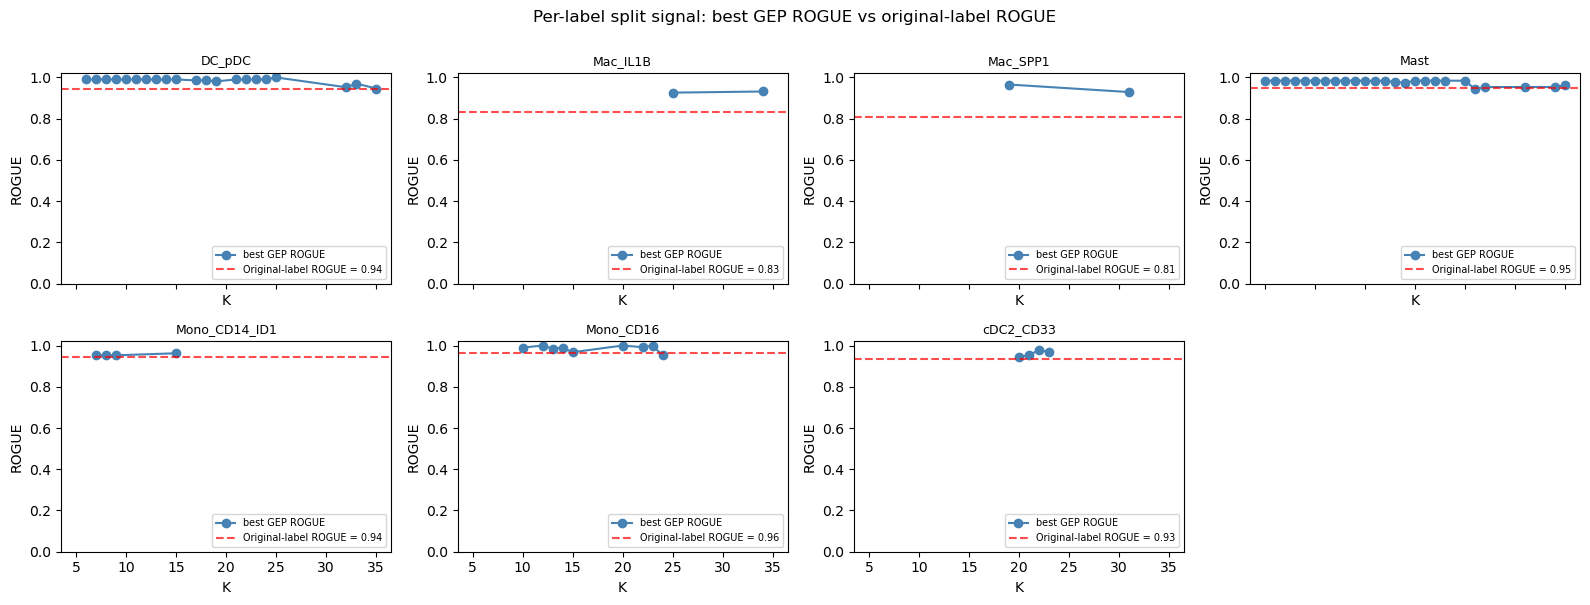

In [16]:
# 9a — Per-label split signal across K

specific_audit = audit_df[audit_df['label_kind'] == 'specific'].copy()

# best (K, GEP) per (label, K): max ROGUE across GEPs and samples carrying that label
per_label_best = (specific_audit
                  .groupby(['label', 'K'])
                  .agg(best_ROGUE=('ROGUE', 'max'),
                       n_rows    =('ROGUE', 'count'))
                  .reset_index())

# Median baseline across samples for that label (line on each subplot)
baseline_by_label = (baseline_specific
                     .groupby('original_label')['ROGUE']
                     .median()
                     .to_dict())

labels_present = sorted(per_label_best['label'].unique())
n = len(labels_present)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, lbl in zip(axes, labels_present):
    df = per_label_best[per_label_best['label'] == lbl].sort_values('K')
    ax.plot(df['K'], df['best_ROGUE'], marker='o', color='steelblue',
            label='best GEP ROGUE')
    base = baseline_by_label.get(lbl, np.nan)
    if not pd.isna(base):
        ax.axhline(base, ls='--', color='red', alpha=0.7,
                   label=f'Original-label ROGUE = {base:.2f}')
    ax.set_title(lbl, fontsize=9)
    ax.set_ylabel('ROGUE')
    ax.set_xlabel('K')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7, loc='lower right')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Per-label split signal: best GEP ROGUE vs original-label ROGUE",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_label_split_signal.png", dpi=150, bbox_inches='tight')
plt.show()

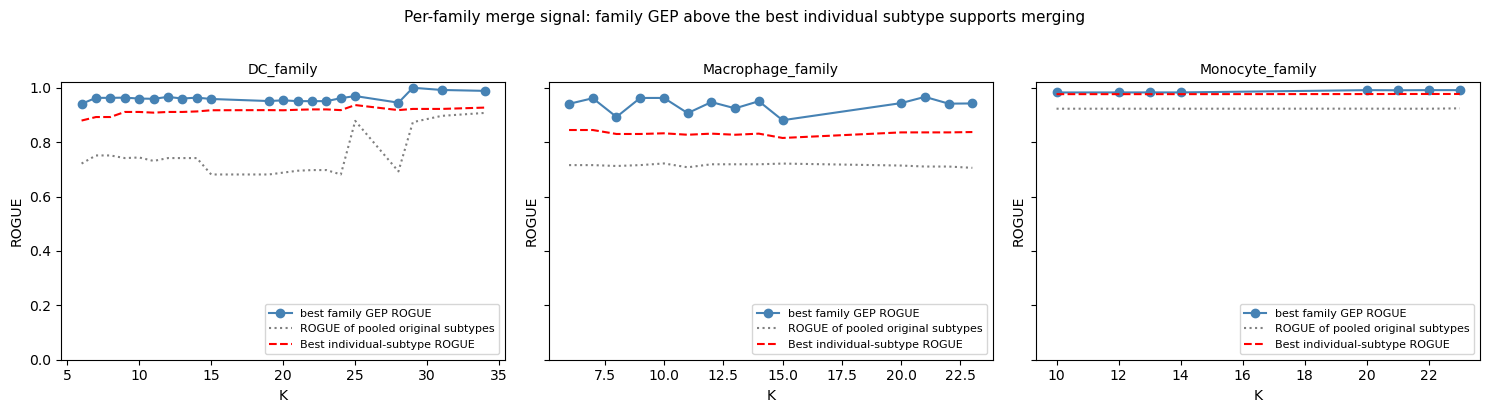

In [17]:
# 9b — Per-family merge signal across K

family_audit = audit_df[audit_df['label_kind'] == 'family'].copy()

per_family_best = (family_audit
                   .groupby(['label', 'K'])
                   .agg(best_ROGUE     =('ROGUE', 'max'),
                        med_pool_base  =('baseline_ROGUE',      'median'),
                        med_mean_base  =('baseline_ROGUE_mean', 'median'),
                        med_max_base   =('baseline_ROGUE_max',  'median'))
                   .reset_index())

families_present = sorted(per_family_best['label'].unique())
n = len(families_present)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, fam_lbl in zip(axes, families_present):
    df = per_family_best[per_family_best['label'] == fam_lbl].sort_values('K')
    ax.plot(df['K'], df['best_ROGUE'],   marker='o', color='steelblue',
            label='best family GEP ROGUE')
    ax.plot(df['K'], df['med_pool_base'], ls=':',  color='gray',
        label='ROGUE of pooled original subtypes')
    ax.plot(df['K'], df['med_max_base'],  ls='--', color='red',
            label='Best individual-subtype ROGUE')
    ax.set_title(fam_lbl, fontsize=10)
    ax.set_xlabel('K')
    ax.set_ylabel('ROGUE')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle("Per-family merge signal: family GEP above the best individual subtype supports merging",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_family_merge_signal.png", dpi=150, bbox_inches='tight')
plt.show()

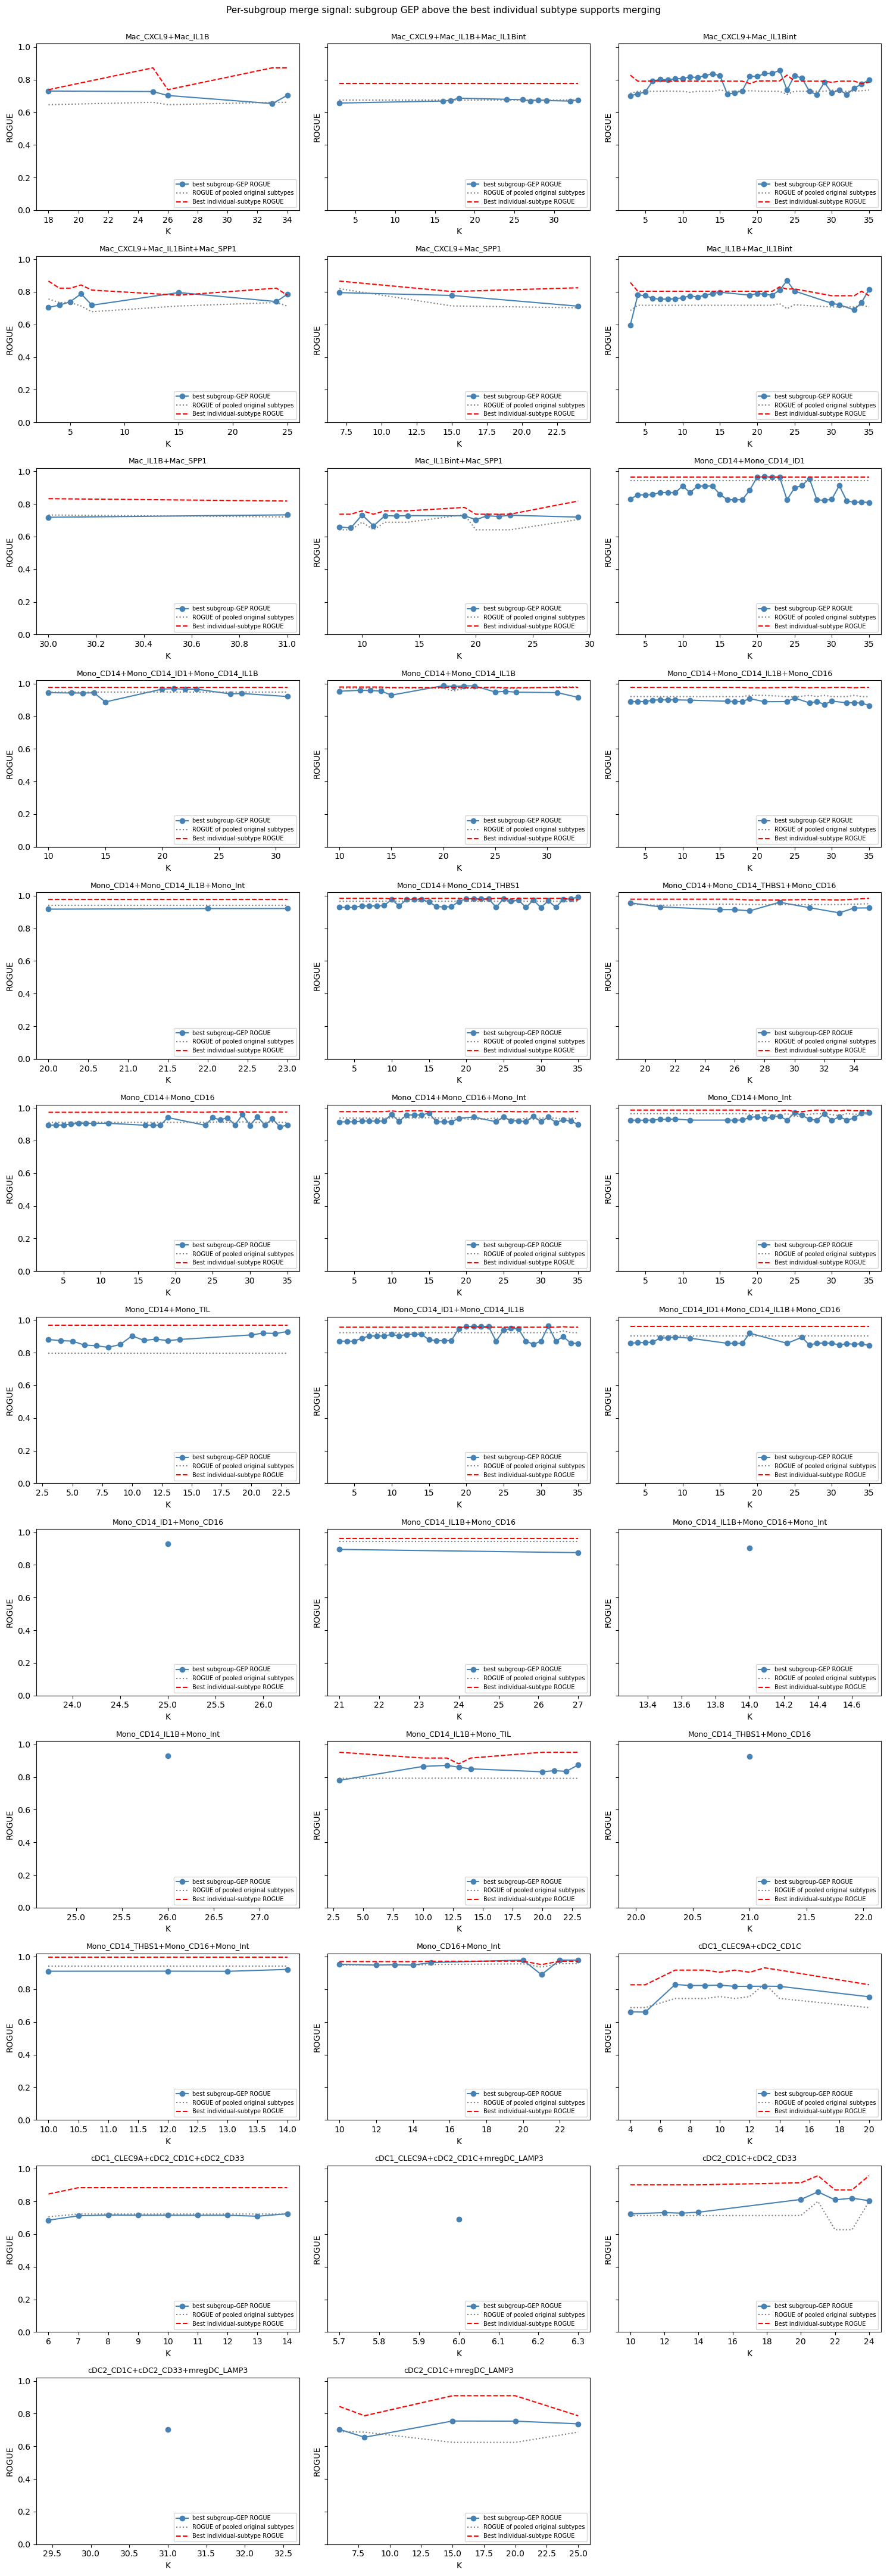

In [18]:
# 9c — Per-subgroup merge signal across K
#
# A subgroup is an empirically-detected partial merge (e.g. Mono_CD14 +
# Mono_CD14_IL1B only). The gray line is the ROGUE of the original constituent subtypes pooled together.
# The red line is the best individual-subtype ROGUE among those same constituents.

subgroup_audit = audit_df[audit_df['baseline_group_type'] == 'subgroup'].copy()

if len(subgroup_audit) == 0:
    print("No subgroup rows in audit_df — skipping 9c.")
else:
    per_subgroup_best = (subgroup_audit
                         .groupby(['membership_label', 'K'])
                         .agg(best_ROGUE     =('ROGUE', 'max'),
                              med_pool_base  =('baseline_ROGUE',      'median'),
                              med_mean_base  =('baseline_ROGUE_mean', 'median'),
                              med_max_base   =('baseline_ROGUE_max',  'median'),
                              n_samples      =('sample', 'nunique'))
                         .reset_index())

    subgroups_present = sorted(per_subgroup_best['membership_label'].unique())
    n = len(subgroups_present)
    cols = min(3, n)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3.6),
                             sharey=True, squeeze=False)
    axes = axes.ravel()

    for ax, sg in zip(axes, subgroups_present):
        df = per_subgroup_best[per_subgroup_best['membership_label'] == sg].sort_values('K')
        ax.plot(df['K'], df['best_ROGUE'],   marker='o', color='steelblue',
                label='best subgroup-GEP ROGUE')
        ax.plot(df['K'], df['med_pool_base'], ls=':',  color='gray',
                label='ROGUE of pooled original subtypes')
        ax.plot(df['K'], df['med_max_base'],  ls='--', color='red',
                label='Best individual-subtype ROGUE')
        ax.set_title(sg, fontsize=9)
        ax.set_xlabel('K')
        ax.set_ylabel('ROGUE')
        ax.set_ylim(0, 1.02)
        ax.legend(fontsize=7, loc='lower right')

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.suptitle("Per-subgroup merge signal: subgroup GEP above the best individual subtype supports merging",
             y=1.00, fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/per_subgroup_merge_signal.png", dpi=150, bbox_inches='tight')
    plt.show()


## 10. Per-label aggregate

Collapses `audit_df` to one row per `membership_label` using `_per_label_aggregate(df, kind)`. For each label group:

1. Find the row with the highest ROGUE — that's the "best" achievement of this label across all (sample, K, GEP) combinations.
2. Compute `baseline_ROGUE_median` from the appropriate baseline table (specific from §6, family from §6b, subgroup from §7c).
3. `best_delta_ROGUE = best['ROGUE'] - base_median`.
4. For family and subgroup, additionally compute `median_best_constituent_baseline`: per sample, take the max over members, then median across samples.
5. Persistence count `n_K_with_signal`: number of distinct K values where at least one GEP exceeded threshold. For specific rows this uses `delta_ROGUE`; for subgroup/family rows this uses `delta_ROGUE_vs_max` — i.e. the strict-merge bar, not the weaker pool bar. This is your "robust across K-selection" check.

Then the three sub-tables (specific, subgroup, family) get concatenated, sorted by `baseline_group_type` then descending `best_delta_ROGUE`, and saved to `rogue_per_label_aggregate.csv`.
This final table is what answers the three split/merge questions in one place: each row tells you, for one `membership_label`, how strong the signal is and how persistent it is across K.


In [19]:
def _per_label_aggregate(df, kind):
    """Collapse audit_df rows of a given baseline_group_type to one row per
    membership_label. For specific: baseline = nb6 specific. For family:
    baseline = nb6b family pool. For subgroup: baseline = nb7c subgroup pool."""
    rows = []
    for lbl, sub in df.groupby('membership_label'):
        if sub['ROGUE'].notna().sum() == 0:
            continue
        idx = sub['ROGUE'].idxmax()
        best = sub.loc[idx]
        members_str = best.get('members_str', '')

        median_best_constituent = np.nan

        if kind == 'specific':
            base_median = (baseline_specific[baseline_specific['original_label'] == lbl]
                           ['ROGUE'].median())
            best_delta = best['ROGUE'] - base_median if not pd.isna(base_median) else np.nan

        elif kind == 'family':
            base_median = (baseline_family[baseline_family['family_label'] == lbl]
                           ['ROGUE'].median())
            fam = lbl[:-len(FAMILY_LABEL_SUFFIX)]
            family_members = CELLTYPE_FAMILIES.get(fam, [])
            constituent_max_medians = []
            for s in sub['sample'].unique():
                vals = [baseline_specific_lookup.get((s, m)) for m in family_members]
                vals = [v for v in vals if v is not None and not np.isnan(v)]
                if vals:
                    constituent_max_medians.append(max(vals))
            median_best_constituent = (float(np.median(constituent_max_medians))
                                       if constituent_max_medians else np.nan)
            best_delta = best['ROGUE'] - base_median if not pd.isna(base_median) else np.nan

        elif kind == 'subgroup':
            # Pool baseline median across samples that carry this exact subgroup
            base_vals = (baseline_subgroup
                         [baseline_subgroup['members_str'] == lbl]['ROGUE']
                         .dropna())
            base_median = float(base_vals.median()) if len(base_vals) else np.nan
            # Best-constituent baseline: per sample, take max over THIS subgroup's
            # members (not the whole family), then median across samples.
            sub_members = lbl.split('+')
            constituent_max_medians = []
            for s in sub['sample'].unique():
                vals = [baseline_specific_lookup.get((s, m)) for m in sub_members]
                vals = [v for v in vals if v is not None and not np.isnan(v)]
                if vals:
                    constituent_max_medians.append(max(vals))
            median_best_constituent = (float(np.median(constituent_max_medians))
                                       if constituent_max_medians else np.nan)
            best_delta = best['ROGUE'] - base_median if not pd.isna(base_median) else np.nan

        else:
            base_median = np.nan
            best_delta  = np.nan

        # Persistence: how many distinct K values had ANY GEP exceeding threshold?
        # For specific → check delta_ROGUE; for subgroup/family → check delta_ROGUE_vs_max.
        if kind == 'specific':
            sig = sub[sub.get('delta_ROGUE', np.nan).fillna(-np.inf)
                      >= DELTA_ROGUE_THRESHOLD]
        else:
            sig = sub[sub.get('delta_ROGUE_vs_max', np.nan).fillna(-np.inf)
                      >= DELTA_ROGUE_THRESHOLD]
        n_K_with_signal = sig['K'].nunique()

        row = {
            'label':                  lbl,              # for backward-compat
            'membership_label':        lbl,
            'label_kind':             kind,             # for backward-compat
            'baseline_group_type':         kind,
            'members_str':            members_str,
            'best_GEP_ROGUE':         best['ROGUE'],
            'K_at_best':              int(best['K']),
            'GEP_at_best':            best['gep'],
            'sample_at_best':         best['sample'],
            'baseline_ROGUE_median':  base_median,
            'best_delta_ROGUE':       best_delta,
            'n_K_with_signal':        n_K_with_signal,
            'n_rows':                 len(sub),
        }
        if kind in ('family', 'subgroup'):
            row['median_best_constituent_baseline'] = median_best_constituent
        rows.append(row)
    return pd.DataFrame(rows)


per_label_specific = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'specific'], 'specific')
per_label_subgroup = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'subgroup'], 'subgroup')
per_label_family   = _per_label_aggregate(
    audit_df[audit_df['baseline_group_type'] == 'family'],   'family')

per_label_agg = pd.concat([per_label_specific, per_label_subgroup, per_label_family],
                          ignore_index=True, sort=False)
per_label_agg = per_label_agg.sort_values(
    ['baseline_group_type', 'best_delta_ROGUE'],
    ascending=[True, False],
    na_position='last',
).reset_index(drop=True)

out = os.path.join(OUT_DIR, "rogue_per_label_aggregate.csv")
per_label_agg.to_csv(out, index=False)
print(f"Saved per-label aggregate → {out}")
print(f"\nRow counts by baseline_group_type:")
print(per_label_agg['baseline_group_type'].value_counts().to_string())
per_label_agg


Saved per-label aggregate → rogue_purity_results_per_gep/rogue_per_label_aggregate.csv

Row counts by baseline_group_type:
baseline_group_type
subgroup    35
specific     7
family       3


,label,membership_label,label_kind,baseline_group_type,members_str,best_GEP_ROGUE,K_at_best,GEP_at_best,sample_at_best,baseline_ROGUE_median,best_delta_ROGUE,n_K_with_signal,n_rows,median_best_constituent_baseline
0,Macrophage_family,Macrophage_family,family,family,,0.966563,21,3,GSM4138143,0.712397,0.254167,12,189,0.849288
1,DC_family,DC_family,family,family,Mono_CD14_THBS1,1.000000,29,3,GSM4138116,0.898821,0.101179,15,586,0.922182
2,Monocyte_family,Monocyte_family,family,family,Mono_CD14,0.991339,22,1,GSM4138132,0.911895,0.079444,3,305,0.976261
3,Mac_SPP1,Mac_SPP1,specific,specific,Mono_CD14,0.965779,19,1,GSM4138132,0.808414,0.157364,1,37,NaN
4,Mac_IL1B,Mac_IL1B,specific,specific,,0.931949,34,3,GSM4138111,0.831312,0.100637,0,25,NaN
5,DC_pDC,DC_pDC,specific,specific,,1.000000,25,4,GSM4138157,0.944275,0.055725,3,661,NaN
6,cDC2_CD33,cDC2_CD33,specific,specific,,0.977712,22,2,GSM4138159,0.934087,0.043625,0,157,NaN
7,Mono_CD16,Mono_CD16,specific,specific,,1.000000,12,2,GSM4138129,0.964002,0.035998,2,208,NaN
8,Mast,Mast,specific,specific,Mast,0.984348,5,5,GSM4138117,0.949910,0.034438,5,159,NaN
9,Mono_CD14_ID1,Mono_CD14_ID1,specific,specific,Mono_CD14,0.960762,15,1,GSM4138134,0.943186,0.017576,0,147,NaN
